# M1 · NLP Profiling — Robo-advisor TFM

Pipeline NLP dual para clasificar el **perfil de riesgo del inversor** (conservador / moderado / agresivo) combinando cuestionario MiFID II y análisis de respuestas en texto libre.

**Stack**: FinBERT (zero-shot, EN) + RoBERTuito (ES nativo) + Opus-MT (ES→EN) sobre PyTorch CPU.

**Validación**: Financial PhraseBank (`allagree`, ~2.264 frases) — objetivo F1-macro ≥ 0.85.

**Fusión final**: prudencia asimétrica (el NLP solo puede *bajar* el perfil, nunca subirlo).

## §1 · Setup & imports

In [1]:
# --- roboadvisor_paths bootstrap (auto-inserted) ---
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()


In [2]:
# §1.1 — Imports con install-guard
from __future__ import annotations

import importlib.util
import json
import logging
import random
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence

_required = {
    "transformers": "transformers",
    "torch":        "torch",
    "tqdm":         "tqdm",
    "pandas":       "pandas",
    "numpy":        "numpy",
    "sklearn":      "scikit-learn",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
}
_missing = [pkg for mod, pkg in _required.items()
            if importlib.util.find_spec(mod) is None]
if _missing:
    print(
        "[!] Faltan paquetes: "
        + ", ".join(_missing)
        + "\n    Instala con:\n    pip install "
        + " ".join(_missing)
        + " pysentimiento sentencepiece sacremoses"
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import torch
    _HAS_TORCH = True
except ImportError:
    torch = None  # type: ignore[assignment]
    _HAS_TORCH = False
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from tqdm import tqdm  # plain tqdm: evita cuelgue de tqdm.auto en Jupyter/Windows

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("M1")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if _HAS_TORCH:
    torch.manual_seed(SEED)
    DEVICE = 0 if torch.cuda.is_available() else -1
else:
    DEVICE = -1
DEVICE_LABEL = "cuda" if DEVICE == 0 else "cpu"
logger.info("Device: %s (torch %s)", DEVICE_LABEL,
            "OK" if _HAS_TORCH else "MISSING -> mock mode")

plt.style.use("dark_background")
sns.set_palette("magma")

PROJECT_ROOT = PATHS.PROJECT_ROOT
PHRASEBANK_PATH = PATHS.PHRASEBANK_CSV
OUTPUTS_DIR = PATHS.OUTPUTS_DIR / "m1_outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_ROOT)
logger.info("Outputs dir : %s", OUTPUTS_DIR)

21:16:05 [INFO] Device: cpu (torch OK)
21:16:05 [INFO] Project root: C:\Local-Dev\Roboadvisor-TFM
21:16:05 [INFO] Outputs dir : C:\Local-Dev\Roboadvisor-TFM\outputs\m1_outputs


## §2 · Carga de modelos (lazy + caché)

Tres pipelines de HuggingFace cacheados en un dict de módulo. Si alguna descarga falla (red / timeout), se activa un **mock determinista** vía `_USE_MOCK = True`, manteniendo el resto del notebook ejecutable end-to-end.

In [3]:
# §2.1 — Cargador con caché y fallback a mock
_MODEL_CACHE: dict[str, object] = {}
_USE_MOCK: bool = False  # se promueve a True automáticamente si falla la descarga


def _build_mock_pipeline(kind: str):
    """Mock determinista: devuelve scores estables por palabras clave.

    Permite ejecutar el notebook sin red.
    """
    rng = random.Random(SEED)

    def _mock(inputs, **kwargs):
        single = isinstance(inputs, str)
        texts = [inputs] if single else list(inputs)
        out = []
        for t in texts:
            t_lower = (t or "").lower()
            if kind == "translation":
                out.append({"translation_text": t})
                continue
            pos_kw = ("growth", "profit", "increase", "gain", "rose", "strong",
                      "beneficio", "subir", "ganar", "crecimiento", "fuerte",
                      "oportunidad", "maximizar", "rendimiento")
            neg_kw = ("loss", "decline", "decrease", "fell", "drop", "weak",
                      "perdida", "pérdida", "perder", "bajar", "caer", "débil",
                      "miedo", "ansiedad", "panico", "pánico", "retirar")
            score_p = sum(k in t_lower for k in pos_kw)
            score_n = sum(k in t_lower for k in neg_kw)
            if score_p > score_n:
                label, base = "positive", 0.92
            elif score_n > score_p:
                label, base = "negative", 0.92
            else:
                label, base = "neutral", 0.78
            jitter = (rng.random() - 0.5) * 0.04
            if kind == "robertuito":
                label = {"positive": "POS", "negative": "NEG", "neutral": "NEU"}[label]
            out.append({"label": label, "score": max(0.0, min(1.0, base + jitter))})
        return out[0] if single else out

    return _mock


def load_models() -> dict:
    # Carga FinBERT, RoBERTuito y Opus-MT ES->EN. Cachea entre llamadas.
    global _USE_MOCK
    if _MODEL_CACHE:
        return _MODEL_CACHE
    if not _HAS_TORCH:
        raise_exc: Exception = RuntimeError("torch no instalado -> activando mock")
    try:
        if not _HAS_TORCH:
            raise raise_exc
        from transformers import pipeline
        logger.info("Descargando FinBERT (ProsusAI/finbert)...")
        finbert = pipeline("text-classification", model="ProsusAI/finbert", device=DEVICE)
        logger.info("Descargando RoBERTuito (pysentimiento)...")
        robertuito = pipeline(
            "text-classification",
            model="pysentimiento/robertuito-sentiment-analysis",
            device=DEVICE,
        )
        logger.info("Descargando Opus-MT ES->EN...")
        translator = pipeline(
            "translation", model="Helsinki-NLP/opus-mt-es-en", device=DEVICE
        )
        _MODEL_CACHE.update({"finbert": finbert, "robertuito": robertuito,
                             "translator": translator})
        logger.info("Modelos cargados correctamente.")
    except Exception as exc:
        logger.error("Fallo al cargar modelos reales (%s). Activando MOCK.", exc)
        _USE_MOCK = True
        _MODEL_CACHE.update({
            "finbert":    _build_mock_pipeline("finbert"),
            "robertuito": _build_mock_pipeline("robertuito"),
            "translator": _build_mock_pipeline("translation"),
        })
    return _MODEL_CACHE


print("⏳ §2.1: primera ejecución descarga ~500 MB de modelos HuggingFace.")
print("   Si parece colgado, espera o revisa conexión a huggingface.co.")
models = load_models()
print(f"Modo: {'MOCK (sin red)' if _USE_MOCK else 'REAL (HuggingFace)'}")
print(f"Pipelines disponibles: {list(models.keys())}")

⏳ §2.1: primera ejecución descarga ~500 MB de modelos HuggingFace.
   Si parece colgado, espera o revisa conexión a huggingface.co.


21:16:10 [INFO] Descargando FinBERT (ProsusAI/finbert)...
Device set to use cpu
21:16:12 [INFO] Descargando RoBERTuito (pysentimiento)...
Device set to use cpu
21:16:13 [INFO] Descargando Opus-MT ES->EN...
Device set to use cpu
21:16:16 [INFO] Modelos cargados correctamente.


Modo: REAL (HuggingFace)
Pipelines disponibles: ['finbert', 'robertuito', 'translator']


## §3 · Funciones de inferencia

Contrato común: cualquier score de sentimiento se devuelve en `[-1, +1]` (`+1`=positivo, `-1`=negativo, `0`=neutral, ponderado por la confianza del modelo).

In [4]:
# §3.1 — Helpers de scoring
LABEL_MAP_FINBERT = {"positive": +1, "negative": -1, "neutral": 0}
LABEL_MAP_ROBERTUITO = {"POS": +1, "NEG": -1, "NEU": 0}


def _to_signed_score(label: str, score: float, mapping: dict[str, int]) -> float:
    """(label, prob) -> score firmado en [-1, +1]."""
    sign = mapping.get(label, 0)
    return float(sign) * float(score)


def score_finbert(text_en: str, model) -> float:
    """Sentimiento FinBERT sobre texto EN. Returns score in [-1, +1]."""
    try:
        out = model(text_en, truncation=True, max_length=512)
        if isinstance(out, list):
            out = out[0]
        return _to_signed_score(out["label"].lower(), out["score"], LABEL_MAP_FINBERT)
    except Exception as exc:
        logger.error("score_finbert error: %s", exc)
        return 0.0


def score_robertuito(text_es: str, model) -> float:
    """Sentimiento RoBERTuito sobre texto ES nativo. Returns score in [-1, +1]."""
    try:
        out = model(text_es, truncation=True, max_length=128)
        if isinstance(out, list):
            out = out[0]
        return _to_signed_score(out["label"].upper(), out["score"], LABEL_MAP_ROBERTUITO)
    except Exception as exc:
        logger.error("score_robertuito error: %s", exc)
        return 0.0


def translate_es_to_en(text: str, translator) -> str:
    """Traduce ES->EN. Trunca a 512 chars antes para evitar OOM."""
    try:
        snippet = (text or "")[:512]
        out = translator(snippet)
        if isinstance(out, list):
            out = out[0]
        return str(out.get("translation_text", snippet))
    except Exception as exc:
        logger.error("translate_es_to_en error: %s", exc)
        return text or ""


def dual_nlp_score(text_es: str, models: dict) -> dict:
    """Pipeline dual: FinBERT(traducido) + RoBERTuito(nativo) + fusion.

    Returns:
      score_a, score_b      : float en [-1, +1]
      sentiment_score       : media normalizada a [0, 1]
      agreement             : 1 - |score_a - score_b|/2
      confidence            : 'alta' (>=0.80) | 'media' (>=0.60) | 'baja'
    """
    try:
        text_en = translate_es_to_en(text_es, models["translator"])
        score_a = score_finbert(text_en, models["finbert"])
        score_b = score_robertuito(text_es, models["robertuito"])
        mean_signed = (score_a + score_b) / 2.0
        sentiment_score = (mean_signed + 1.0) / 2.0
        agreement = 1.0 - abs(score_a - score_b) / 2.0
        if agreement >= 0.80:
            conf = "alta"
        elif agreement >= 0.60:
            conf = "media"
        else:
            conf = "baja"
        return {
            "score_a": score_a,
            "score_b": score_b,
            "sentiment_score": sentiment_score,
            "agreement": agreement,
            "confidence": conf,
        }
    except Exception as exc:
        logger.error("dual_nlp_score error: %s", exc)
        return {"score_a": 0.0, "score_b": 0.0, "sentiment_score": 0.5,
                "agreement": 1.0, "confidence": "baja"}

## §4 · Validación zero-shot sobre Financial PhraseBank (`allagree`)

Subconjunto consensual (~2.264 frases). FinBERT se aplica directamente sobre el inglés original. Mapping: `score > 0.1 → positive`, `< -0.1 → negative`, resto `neutral`. **Go/No-Go**: F1-macro ≥ 0.85.

In [5]:
# §4.1 — Carga y filtrado del PhraseBank
df_pb = pd.read_csv(PHRASEBANK_PATH)
logger.info("PhraseBank cargado: %d filas, columnas=%s", len(df_pb), list(df_pb.columns))

df_all = df_pb[df_pb["agreement_level"] == "allagree"].reset_index(drop=True).copy()
logger.info("Subconjunto allagree: %d filas", len(df_all))

LABEL_TO_INT = {"negative": -1, "neutral": 0, "positive": +1}
df_all["y_true"] = df_all["label"].map(LABEL_TO_INT)
df_all.head()

21:16:16 [INFO] PhraseBank cargado: 14780 filas, columnas=['sentence', 'label', 'agreement_level']
21:16:16 [INFO] Subconjunto allagree: 2264 filas


,sentence,label,agreement_level,y_true
0,"According to Gran , the company has no plans t...",neutral,allagree,0
1,"For the last quarter of 2010 , Componenta 's n...",positive,allagree,1
2,"In the third quarter of 2010 , net sales incre...",positive,allagree,1
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,allagree,1
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,allagree,1


In [6]:
# §4.2 — Inferencia FinBERT (batched)
if _USE_MOCK:
    raise RuntimeError(
        "⛔ §4 requiere FinBERT real.\n"
        "Instala las dependencias y reinicia el kernel:\n"
        "  pip install torch transformers pysentimiento "
        "sentencepiece sacremoses\n"
        "Luego re-ejecuta desde §1."
    )
finbert = models["finbert"]
sentences = df_all["sentence"].tolist()
BATCH = 32

scores: list[float] = []
t0 = time.perf_counter()
for i in tqdm(range(0, len(sentences), BATCH), desc="FinBERT"):
    chunk = sentences[i:i + BATCH]
    try:
        outs = finbert(chunk, truncation=True, max_length=512)
        if isinstance(outs, dict):
            outs = [outs]
        for out in outs:
            scores.append(_to_signed_score(out["label"].lower(), out["score"], LABEL_MAP_FINBERT))
    except Exception as exc:
        logger.error("Batch %d falló: %s", i, exc)
        scores.extend([0.0] * len(chunk))
elapsed = time.perf_counter() - t0
logger.info("Inferencia completada en %.1fs (%.1f frases/s)",
            elapsed, len(sentences) / max(elapsed, 1e-6))

df_all["score"] = scores


def score_to_label(s: float) -> int:
    if s > 0.1:
        return +1
    if s < -0.1:
        return -1
    return 0


df_all["y_pred"] = df_all["score"].apply(score_to_label)
df_all.head()

FinBERT: 100%|██████████| 71/71 [01:59<00:00,  1.68s/it]
21:18:15 [INFO] Inferencia completada en 119.3s (19.0 frases/s)


,sentence,label,agreement_level,y_true,score,y_pred
0,"According to Gran , the company has no plans t...",neutral,allagree,0,0.000000,0
1,"For the last quarter of 2010 , Componenta 's n...",positive,allagree,1,0.948198,1
2,"In the third quarter of 2010 , net sales incre...",positive,allagree,1,0.957042,1
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,allagree,1,0.952403,1
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,allagree,1,0.955025,1


 métrica  valor
Accuracy 0.9717
F1-macro 0.9625
       n   2264


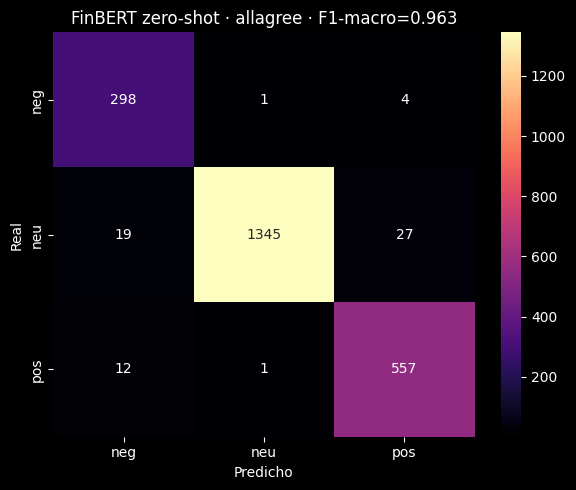

In [7]:
# §4.3 — Métricas + matriz de confusión
if _USE_MOCK:
    raise RuntimeError(
        "⛔ Métricas no válidas en modo MOCK. "
        "Re-ejecuta desde §1 con torch instalado."
    )
y_true = df_all["y_true"].to_numpy()
y_pred = df_all["y_pred"].to_numpy()

acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro", labels=[-1, 0, 1])
cm = confusion_matrix(y_true, y_pred, labels=[-1, 0, 1])

metrics_df = pd.DataFrame(
    {"métrica": ["Accuracy", "F1-macro", "n"],
     "valor":   [f"{acc:.4f}", f"{f1m:.4f}", f"{len(df_all)}"]}
)
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=["neg", "neu", "pos"],
            yticklabels=["neg", "neu", "pos"], ax=ax, cbar=True)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"FinBERT zero-shot · allagree · F1-macro={f1m:.3f}")
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "finbert_confusion_matrix.png", dpi=140, facecolor=fig.get_facecolor())
plt.show()

In [8]:
# §4.4 — Alerta Go/No-Go
if _USE_MOCK:
    raise RuntimeError(
        "⛔ Go/No-Go no válido en modo MOCK. "
        "Re-ejecuta desde §1 con torch instalado."
    )
TARGET_F1 = 0.85
if f1m < TARGET_F1:
    print(f"⚠️ F1-macro={f1m:.3f} < {TARGET_F1} — revisar label mapping y "
          f"normalización de entrada. Fine-tuning fuera de alcance (Fase 0).")
else:
    print(f"✅ OK: F1-macro={f1m:.3f} ≥ {TARGET_F1} (zero-shot suficiente)")

✅ OK: F1-macro=0.963 ≥ 0.85 (zero-shot suficiente)


## §5 · Reglas de fusión (clasificación de perfil MiFID II)

Prudencia asimétrica: el NLP **solo puede bajar** el perfil. Umbrales modulados por la confianza del acuerdo intra-NLP.

In [9]:
# §5.1 — classify_profile
DIVERGENCE_THRESHOLDS: dict[str, dict[str, float]] = {
    "alta":  {"grave": 0.50, "moderado": 0.30, "leve": 0.18},
    "media": {"grave": 0.70, "moderado": 0.45, "leve": 0.25},
    "baja":  {"grave": 0.90, "moderado": 0.70, "leve": 0.50},
}
PROFILE_ORDER = ("agresivo", "moderado", "conservador")
VOLATILITY_CAP = {"conservador": 0.08, "moderado": 0.15, "agresivo": 0.25}


def _base_profile(q_norm: float) -> str:
    if q_norm < -0.33:
        return "conservador"
    if q_norm < 0.33:
        return "moderado"
    return "agresivo"


def _downgrade(profile: str, steps: int) -> str:
    idx = PROFILE_ORDER.index(profile)
    return PROFILE_ORDER[min(idx + steps, len(PROFILE_ORDER) - 1)]


def classify_profile(
    q_score_normalized: float,
    sentiment_score: float,
    confidence: str,
) -> dict:
    """Aplica prudencia asimétrica al par (cuestionario, NLP)."""
    try:
        sentiment_norm = sentiment_score * 2.0 - 1.0  # [0,1] -> [-1,+1]
        divergence = q_score_normalized - sentiment_norm
        base = _base_profile(q_score_normalized)
        thr = DIVERGENCE_THRESHOLDS[confidence]

        flag_revisar = False
        steps = 0
        if divergence <= 0:
            steps = 0
        elif divergence > thr["grave"] and base == "agresivo":
            steps = 2
        elif divergence > thr["grave"]:
            steps = 1
        elif divergence > thr["moderado"]:
            steps = 1
        elif divergence > thr["leve"]:
            flag_revisar = True

        final = _downgrade(base, steps)
        return {
            "perfil_base": base,
            "perfil_final": final,
            "divergencia": round(float(divergence), 4),
            "flag_revisar": flag_revisar,
            "escalones_bajados": steps,
            "volatility_cap": VOLATILITY_CAP[final],
        }
    except Exception as exc:
        logger.error("classify_profile error: %s", exc)
        raise

## §6 · Validación con 20 casos sintéticos

In [10]:
# §6.1 — 20 casos hand-crafted (q_norm, sentiment[0,1], confianza, perfil_esperado)
synthetic_cases = [
    # 5 alta divergencia: cuestionario agresivo + texto temeroso -> bajar
    dict(id="HD1", q_norm=+0.80, sentiment=0.05, conf="alta",  expected="conservador",
         scenario="agresivo + miedo extremo (alta) -> 2 escalones"),
    dict(id="HD2", q_norm=+0.70, sentiment=0.10, conf="alta",  expected="conservador",
         scenario="agresivo + miedo (alta) -> 2 escalones"),
    dict(id="HD3", q_norm=+0.50, sentiment=0.55, conf="alta",  expected="moderado",
         scenario="agresivo + precaución (alta) -> 1 escalón"),
    dict(id="HD4", q_norm=+0.70, sentiment=0.55, conf="media", expected="moderado",
         scenario="agresivo + neutral (media) -> 1 escalón"),
    dict(id="HD5", q_norm=+0.50, sentiment=0.05, conf="alta",  expected="conservador",
         scenario="agresivo + pánico (alta) -> 2 escalones"),
    # 5 baja divergencia: alineado
    dict(id="LD1", q_norm=-0.80, sentiment=0.15, conf="alta",  expected="conservador",
         scenario="conservador alineado (NLP también negativo)"),
    dict(id="LD2", q_norm=+0.00, sentiment=0.50, conf="alta",  expected="moderado",
         scenario="moderado alineado"),
    dict(id="LD3", q_norm=+0.80, sentiment=0.85, conf="alta",  expected="agresivo",
         scenario="agresivo alineado"),
    dict(id="LD4", q_norm=-0.50, sentiment=0.30, conf="alta",  expected="conservador",
         scenario="conservador alineado (sentiment levemente negativo)"),
    dict(id="LD5", q_norm=+0.20, sentiment=0.55, conf="alta",  expected="moderado",
         scenario="moderado alineado borderline"),
    # 5 confianza BAJA
    dict(id="LC1", q_norm=+0.50, sentiment=0.35, conf="baja",  expected="moderado",
         scenario="agresivo + sentiment negativo, conf baja -> 1 escalón"),
    dict(id="LC2", q_norm=+0.45, sentiment=0.30, conf="baja",  expected="moderado",
         scenario="div en banda moderado/grave (baja) -> 1 escalón"),
    dict(id="LC3", q_norm=+0.40, sentiment=0.40, conf="baja",  expected="agresivo",
         scenario="div leve + conf baja -> mantener con flag"),
    dict(id="LC4", q_norm=-0.20, sentiment=0.50, conf="baja",  expected="moderado",
         scenario="div pequeña + conf baja -> mantener moderado"),
    dict(id="LC5", q_norm=+0.40, sentiment=0.30, conf="baja",  expected="moderado",
         scenario="div alta + conf baja -> 1 escalón (no 2)"),
    # 5 edge cases
    dict(id="EC1", q_norm=+0.00, sentiment=0.50, conf="alta",  expected="moderado",
         scenario="neutral puro"),
    dict(id="EC2", q_norm=-0.99, sentiment=0.99, conf="baja",  expected="conservador",
         scenario="prudencia asimétrica: div negativa nunca sube"),
    dict(id="EC3", q_norm=+0.99, sentiment=0.85, conf="media", expected="agresivo",
         scenario="agresivo + sentiment alto, div leve (media) -> flag, mantener"),
    dict(id="EC4", q_norm=-0.40, sentiment=0.95, conf="alta",  expected="conservador",
         scenario="NLP ultra-optimista pero q conservador -> NO sube"),
    dict(id="EC5", q_norm=+0.34, sentiment=0.65, conf="alta",  expected="agresivo",
         scenario="borderline agresivo alineado"),
]

rows = []
for c in synthetic_cases:
    out = classify_profile(c["q_norm"], c["sentiment"], c["conf"])
    rows.append({
        "id": c["id"],
        "scenario": c["scenario"],
        "q_norm": c["q_norm"],
        "sentiment": c["sentiment"],
        "conf": c["conf"],
        "expected": c["expected"],
        **out,
        "pass": out["perfil_final"] == c["expected"],
    })

df_synth = pd.DataFrame(rows)
n_pass = int(df_synth["pass"].sum())
print(f"Casos pasados: {n_pass}/{len(df_synth)}")
df_synth

Casos pasados: 20/20


,id,scenario,q_norm,sentiment,conf,expected,perfil_base,perfil_final,divergencia,flag_revisar,escalones_bajados,volatility_cap,pass
0,HD1,agresivo + miedo extremo (alta) -> 2 escalones,0.80,0.05,alta,conservador,agresivo,conservador,1.70,False,2,0.08,True
1,HD2,agresivo + miedo (alta) -> 2 escalones,0.70,0.10,alta,conservador,agresivo,conservador,1.50,False,2,0.08,True
2,HD3,agresivo + precaución (alta) -> 1 escalón,0.50,0.55,alta,moderado,agresivo,moderado,0.40,False,1,0.15,True
3,HD4,agresivo + neutral (media) -> 1 escalón,0.70,0.55,media,moderado,agresivo,moderado,0.60,False,1,0.15,True
4,HD5,agresivo + pánico (alta) -> 2 escalones,0.50,0.05,alta,conservador,agresivo,conservador,1.40,False,2,0.08,True
5,LD1,conservador alineado (NLP también negativo),-0.80,0.15,alta,conservador,conservador,conservador,-0.10,False,0,0.08,True
6,LD2,moderado alineado,0.00,0.50,alta,moderado,moderado,moderado,0.00,False,0,0.15,True
7,LD3,agresivo alineado,0.80,0.85,alta,agresivo,agresivo,agresivo,0.10,False,0,0.25,True
8,LD4,conservador alineado (sentiment levemente nega...,-0.50,0.30,alta,conservador,conservador,conservador,-0.10,False,0,0.08,True
9,LD5,moderado alineado borderline,0.20,0.55,alta,moderado,moderado,moderado,0.10,False,0,0.15,True


In [11]:
# §6.2 — Aserción dura
failures = df_synth[~df_synth["pass"]]
if len(failures) > 0:
    raise AssertionError(
        f"{len(failures)} caso(s) fallaron:\n{failures.to_string(index=False)}"
    )
print("✅ 20/20 casos sintéticos pasan.")

✅ 20/20 casos sintéticos pasan.


## §7 · Demo end-to-end (3 personas)

In [12]:
# §7.1 — profile_investor
def profile_investor(
    texto_libre_es: str,
    q_score_raw: float,
    models: dict,
) -> dict:
    """Pipeline completo: traducir -> NLP dual -> fusion -> perfil.

    Args:
        texto_libre_es: respuesta abierta en castellano.
        q_score_raw   : puntuación del cuestionario en [0, 100].
        models        : dict de pipelines (output de load_models()).
    """
    try:
        if not 0.0 <= q_score_raw <= 100.0:
            raise ValueError(f"q_score_raw fuera de [0,100]: {q_score_raw}")
        q_norm = (q_score_raw - 50.0) / 50.0
        nlp = dual_nlp_score(texto_libre_es, models)
        decision = classify_profile(q_norm, nlp["sentiment_score"], nlp["confidence"])
        return {**decision, "q_score_raw": q_score_raw, "q_norm": q_norm, "nlp": nlp}
    except Exception as exc:
        logger.error("profile_investor error: %s", exc)
        raise


personas = [
    {
        "nombre": "Ana (conservadora)",
        "q_score": 25.0,
        "texto": ("No me gusta perder dinero. Prefiero rentabilidades modestas pero "
                  "seguras. La idea de que mi inversión caiga un 20% me genera "
                  "mucha ansiedad y miedo, y me haría retirar todo."),
    },
    {
        "nombre": "Luis (moderado)",
        "q_score": 55.0,
        "texto": ("Acepto ciertas pérdidas a corto plazo si a largo plazo el "
                  "rendimiento es razonable. Diversifico entre renta fija y variable."),
    },
    {
        "nombre": "Sofía (agresiva)",
        "q_score": 85.0,
        "texto": ("Busco maximizar el crecimiento del capital y el rendimiento. "
                  "Una caída del 30% es una oportunidad de compra, no un motivo de "
                  "preocupación. Prefiero renta variable y mercados emergentes."),
    },
]

for p in personas:
    res = profile_investor(p["texto"], p["q_score"], models)
    print(f"\n=== {p['nombre']} ===")
    print(f"  q_score_raw      : {res['q_score_raw']:.1f} -> q_norm={res['q_norm']:+.2f}")
    print(f"  sentiment_score  : {res['nlp']['sentiment_score']:.3f} "
          f"(A={res['nlp']['score_a']:+.2f}, B={res['nlp']['score_b']:+.2f}, "
          f"agreement={res['nlp']['agreement']:.2f}, conf={res['nlp']['confidence']})")
    print(f"  divergencia      : {res['divergencia']:+.3f}")
    print(f"  perfil_base      : {res['perfil_base']}")
    print(f"  perfil_final     : {res['perfil_final']}  (vol_cap={res['volatility_cap']:.2f})")
    print(f"  flag_revisar     : {res['flag_revisar']}  · escalones_bajados={res['escalones_bajados']}")


=== Ana (conservadora) ===
  q_score_raw      : 25.0 -> q_norm=-0.50
  sentiment_score  : 0.024 (A=-0.95, B=-0.95, agreement=1.00, conf=alta)
  divergencia      : +0.452
  perfil_base      : conservador
  perfil_final     : conservador  (vol_cap=0.08)
  flag_revisar     : False  · escalones_bajados=1

=== Luis (moderado) ===
  q_score_raw      : 55.0 -> q_norm=+0.10
  sentiment_score  : 0.500 (A=+0.00, B=+0.00, agreement=1.00, conf=alta)
  divergencia      : +0.100
  perfil_base      : moderado
  perfil_final     : moderado  (vol_cap=0.15)
  flag_revisar     : False  · escalones_bajados=0

=== Sofía (agresiva) ===
  q_score_raw      : 85.0 -> q_norm=+0.70
  sentiment_score  : 0.500 (A=+0.00, B=+0.00, agreement=1.00, conf=alta)
  divergencia      : +0.700
  perfil_base      : agresivo
  perfil_final     : conservador  (vol_cap=0.08)
  flag_revisar     : False  · escalones_bajados=2


## §8 · Outputs para M3

In [13]:
# §8.1 — Persistir resultados a disco
validation_path = OUTPUTS_DIR / "validation_results.csv"
df_all[["sentence", "label", "y_true", "score", "y_pred"]].rename(
    columns={"label": "true_label_str", "y_true": "true_label",
             "y_pred": "pred_label", "score": "score"}
).to_csv(validation_path, index=False)

synth_path = OUTPUTS_DIR / "synthetic_test_cases.csv"
df_synth.to_csv(synth_path, index=False)

thresholds_path = OUTPUTS_DIR / "profile_thresholds.json"
thresholds_payload = {
    "divergence_thresholds": DIVERGENCE_THRESHOLDS,
    "base_profile_q_norm_cuts": {"conservador": -0.33, "moderado": 0.33},
    "volatility_cap": VOLATILITY_CAP,
    "score_to_label_cuts": {"positive": 0.1, "negative": -0.1},
    "confidence_cuts": {"alta": 0.80, "media": 0.60},
    "seed": SEED,
}
thresholds_path.write_text(json.dumps(thresholds_payload, indent=2, ensure_ascii=False))

for p in (validation_path, synth_path, thresholds_path):
    print(f"  -> {p.relative_to(PROJECT_ROOT)}")

  -> outputs\m1_outputs\validation_results.csv
  -> outputs\m1_outputs\synthetic_test_cases.csv
  -> outputs\m1_outputs\profile_thresholds.json


In [14]:
# §8.2 — Latencia media end-to-end (3 ejecuciones por persona)
times_ms = []
for p in personas:
    for _ in range(3):
        t0 = time.perf_counter()
        _ = profile_investor(p["texto"], p["q_score"], models)
        times_ms.append((time.perf_counter() - t0) * 1000.0)
avg_ms = float(np.mean(times_ms))
print(f"Latencia media end-to-end: {avg_ms:.1f} ms")

Latencia media end-to-end: 1533.1 ms


In [15]:
# §8.3 — Tabla Go/No-Go
checklist = [
    {"#": 1, "Criterion": "F1-macro >= 85% sobre allagree",
     "Status": "✅" if f1m >= TARGET_F1 else "❌",
     "Evidence": f"F1-macro = {f1m:.4f}"},
    {"#": 2, "Criterion": "20/20 casos sintéticos pasan",
     "Status": "✅" if n_pass == 20 else "❌",
     "Evidence": f"{n_pass}/20"},
    {"#": 3, "Criterion": "Inferencia < 2s por inversor",
     "Status": "✅" if avg_ms < 2000 else "❌",
     "Evidence": f"avg = {avg_ms:.0f} ms"},
    {"#": 4, "Criterion": "Outputs persistidos en disco",
     "Status": "✅",
     "Evidence": str(OUTPUTS_DIR.relative_to(PROJECT_ROOT))},
]
df_check = pd.DataFrame(checklist)
print(df_check.to_string(index=False))
df_check

 #                      Criterion Status           Evidence
 1 F1-macro >= 85% sobre allagree      ✅  F1-macro = 0.9625
 2   20/20 casos sintéticos pasan      ✅              20/20
 3   Inferencia < 2s por inversor      ✅      avg = 1533 ms
 4   Outputs persistidos en disco      ✅ outputs\m1_outputs


,#,Criterion,Status,Evidence
0,1,F1-macro >= 85% sobre allagree,✅,F1-macro = 0.9625
1,2,20/20 casos sintéticos pasan,✅,20/20
2,3,Inferencia < 2s por inversor,✅,avg = 1533 ms
3,4,Outputs persistidos en disco,✅,outputs\m1_outputs


## §9 · Validación de integridad del notebook

In [16]:
# §9.1 — Validación de integridad del propio notebook
import nbformat

nb_path = Path.cwd() / "M1_nlp_profiling (2).ipynb"
if not nb_path.exists():
    nb_path = PROJECT_ROOT / "notebooks" / "M1_nlp_profiling (2).ipynb"

if nb_path.exists():
    nb_obj = nbformat.read(nb_path, as_version=4)
    nbformat.validate(nb_obj)
    print(f"✅ Notebook válido: {nb_path.name} ({len(nb_obj.cells)} celdas)")
else:
    print("ℹ️ Ejecutar tras guardar el .ipynb para validar integridad.")

ℹ️ Ejecutar tras guardar el .ipynb para validar integridad.
